# Прогнозирование продаж сети Rossmann

## Контекст
Rossmann - одна из крупнейших европейских сетей дрогери (косметика, бытовая химия, товары для здоровья). В датасете представлены **1115 магазинов в Германии**.

## Датасет
[Kaggle: Rossmann Store Sales](https://www.kaggle.com/competitions/rossmann-store-sales) - дневные продажи за 2013-2015 годы.

- `train.csv` - исторические данные с продажами (таргет `Sales`)
- `test.csv` - данные без продаж (для финального предсказания)
- `store.csv` - справочник по магазинам
- `sample_submission.csv` - формат сабмита

## Цель
Построить модель прогнозирования дневных продаж. Сравнить XGBoost / LSTM / GRU, подобрать гиперпараметры, задеплоить в демо (FastAPI).

## Метрики
MAE, RMSE, MAPE.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import os
import json

In [ ]:
import random
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
files.upload()

In [ ]:
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

In [ ]:
!pip install kaggle
!kaggle competitions download -c rossmann-store-sales -p /content/rossmann
!unzip /content/rossmann/rossmann-store-sales.zip -d /content/rossmann

rossmann-store-sales.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/rossmann/rossmann-store-sales.zip
replace /content/rossmann/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/rossmann/sample_submission.csv  
replace /content/rossmann/store.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/rossmann/store.csv  
replace /content/rossmann/test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/rossmann/test.csv  
replace /content/rossmann/train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/rossmann/train.csv  


# ***EDA анализ***

In [ ]:
store = pd.read_csv('/content/rossmann/store.csv')
sample = pd.read_csv('/content/rossmann/sample_submission.csv')
test = pd.read_csv('/content/rossmann/test.csv')
train = pd.read_csv('/content/rossmann/train.csv', low_memory=False)

In [ ]:
train.info()
print('-------')
train.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB
-------


(1017209, 9)

In [ ]:
train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [ ]:
train.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
5,6,5,2015-07-31,5651,589,1,1,0,1
6,7,5,2015-07-31,15344,1414,1,1,0,1
7,8,5,2015-07-31,8492,833,1,1,0,1
8,9,5,2015-07-31,8565,687,1,1,0,1
9,10,5,2015-07-31,7185,681,1,1,0,1


In [ ]:
store.info()
store.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
7,8,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
8,9,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
9,10,a,a,3160.0,9.0,2009.0,0,NaN,NaN,NaN


In [ ]:
print("=== train ===")
print(train.isnull().sum())
print("\n=== store ===")
print(store.isnull().sum())
print("\n=== test ===")
print(test.isnull().sum())

=== train ===
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

=== store ===
Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

=== test ===
Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64


In [ ]:
pd.set_option('display.max.rows', 41089)

In [ ]:
nan_rows = test[test['Open'].isna()]
nan_rows

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
479,480,622,4,2015-09-17,NaN,1,0,0
1335,1336,622,3,2015-09-16,NaN,1,0,0
2191,2192,622,2,2015-09-15,NaN,1,0,0
3047,3048,622,1,2015-09-14,NaN,1,0,0
4759,4760,622,6,2015-09-12,NaN,0,0,0
5615,5616,622,5,2015-09-11,NaN,0,0,0
6471,6472,622,4,2015-09-10,NaN,0,0,0
7327,7328,622,3,2015-09-09,NaN,0,0,0
8183,8184,622,2,2015-09-08,NaN,0,0,0
9039,9040,622,1,2015-09-07,NaN,0,0,0


In [ ]:
train['Open'].value_counts(normalize=True)

,proportion
Open,
1,0.830107
0,0.169893


In [ ]:
test.head(10)

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
5,6,10,4,2015-09-17,1.0,1,0,0
6,7,11,4,2015-09-17,1.0,1,0,0
7,8,12,4,2015-09-17,1.0,1,0,0
8,9,13,4,2015-09-17,1.0,1,0,0
9,10,14,4,2015-09-17,1.0,1,0,0


<Axes: xlabel='Sales', ylabel='Count'>

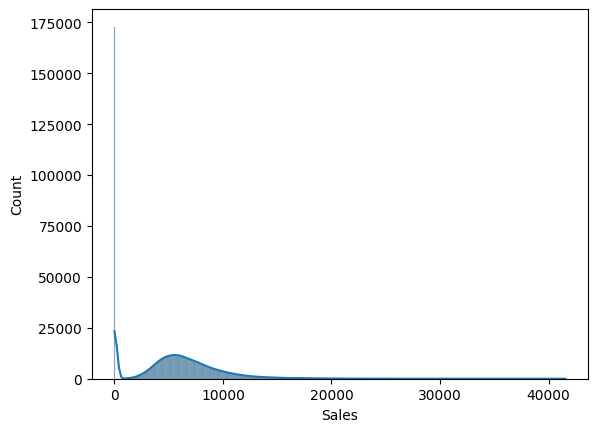

In [ ]:
sns.histplot(data=train, x='Sales', kde=True)

In [ ]:
train_open = train[train['Open'] == 1].copy()
print(f'Было: {len(train)}')
print(f'Стало: {len(train_open)}')

Было: 1017209
Стало: 844392


<Axes: xlabel='Sales', ylabel='Count'>

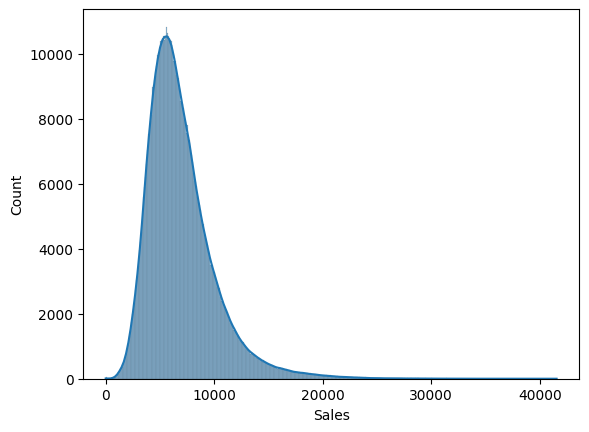

In [ ]:
sns.histplot(data=train_open, x='Sales', kde=True)

In [ ]:
train_open['Date'] = pd.to_datetime(train_open['Date'])
train_open['Date'].dtype

dtype('<M8[ns]')

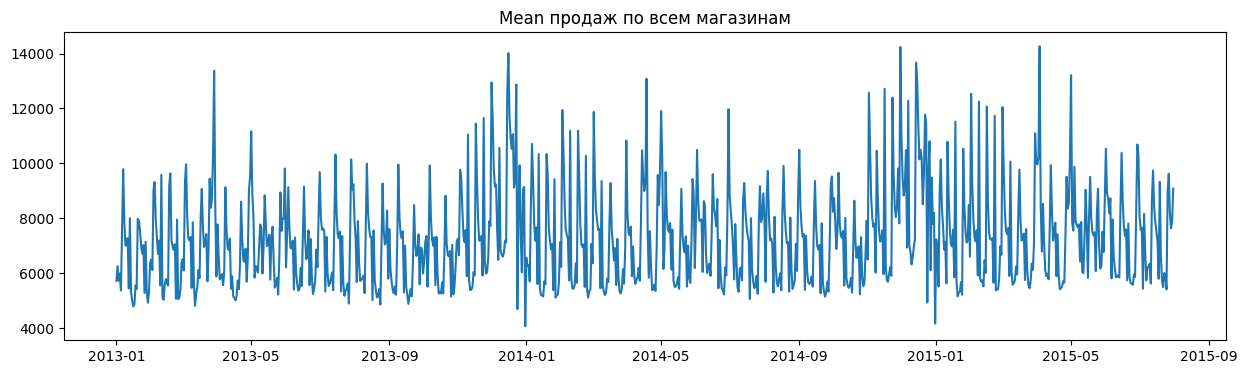

In [ ]:
daily_sales = train_open.groupby('Date')['Sales'].mean()

plt.figure(figsize=(15, 4))
plt.plot(daily_sales)
plt.title('Mean продаж по всем магазинам')
plt.show()

In [ ]:
daily_sales[daily_sales < 2000]

,Sales
Date,


In [ ]:
train_open = train[train['Open'] == 1].copy()
train_open['Date'] = pd.to_datetime(train_open['Date'])

train_merged = train_open.merge(store, on='Store', how='left')

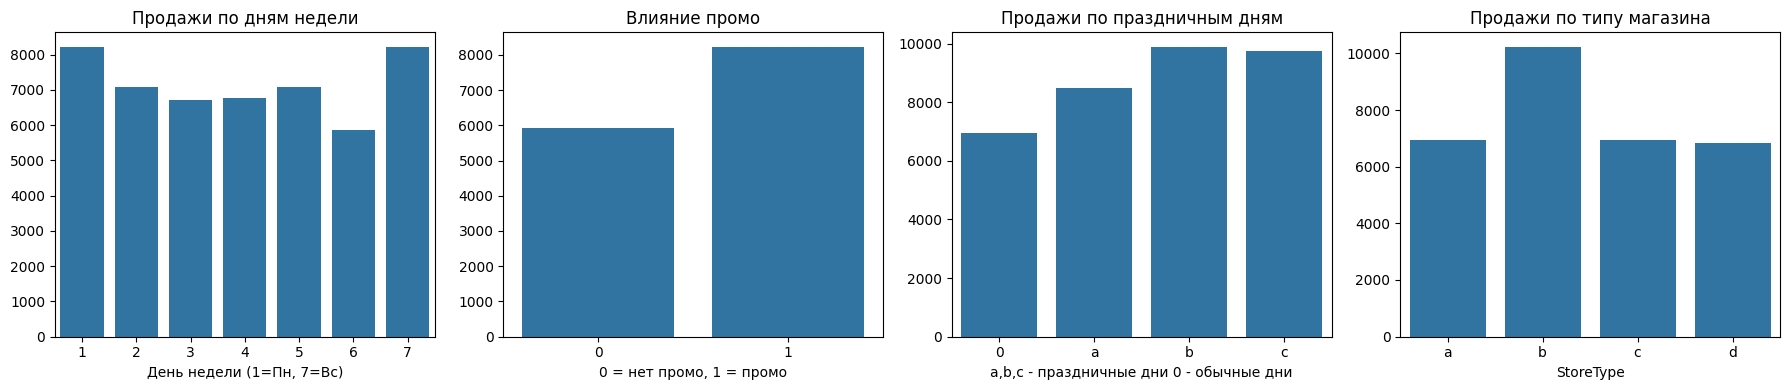

In [ ]:
week_sales = train_open.groupby('DayOfWeek')['Sales'].mean()
promo = train_open.groupby('Promo')['Sales'].mean()
holiday = train_open.groupby('StateHoliday')['Sales'].mean()
storetype = train_merged.groupby('StoreType')['Sales'].mean()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sns.barplot(ax=axes[0], x=week_sales.index, y=week_sales.values)
axes[0].set_title('Продажи по дням недели')
axes[0].set_xlabel('День недели (1=Пн, 7=Вс)')

sns.barplot(ax=axes[1], x=promo.index, y=promo.values)
axes[1].set_title('Влияние промо')
axes[1].set_xlabel('0 = нет промо, 1 = промо')

sns.barplot(ax=axes[2], x=holiday.index, y=holiday.values)
axes[2].set_title('Продажи по праздничным дням')
axes[2].set_xlabel('a,b,c - праздничные дни 0 - обычные дни')

sns.barplot(ax=axes[3], x=storetype.index, y=storetype.values)
axes[3].set_title('Продажи по типу магазина')

plt.tight_layout()
plt.show()

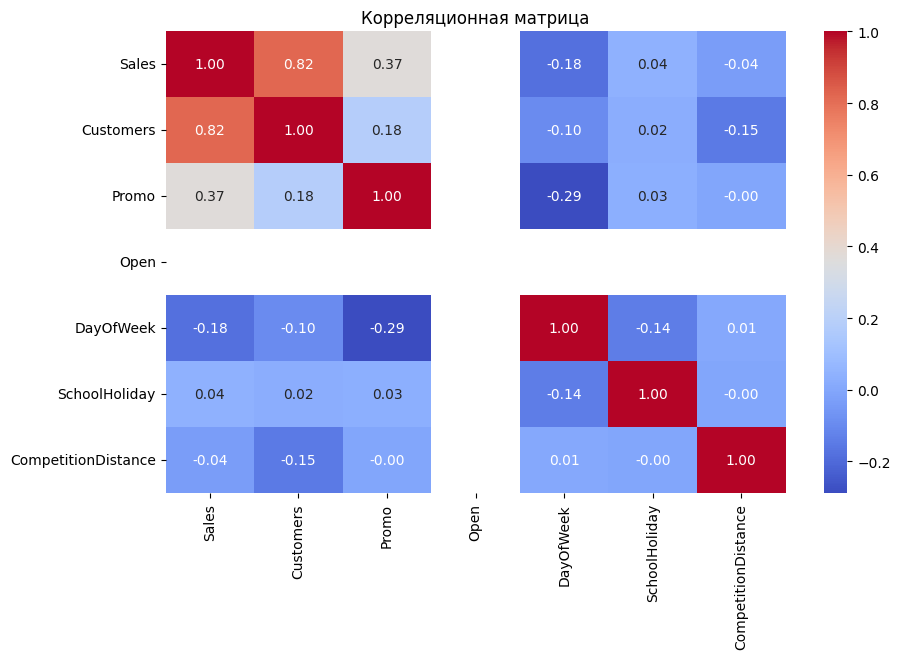

In [ ]:
plt.figure(figsize=(10, 6))
corr = train_merged[['Sales', 'Customers', 'Promo', 'Open',
                       'DayOfWeek', 'SchoolHoliday',
                       'CompetitionDistance']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

## Выводы по EDA

### Качество данных
- `train.csv` - без пропусков
- `store.csv` - пропуски в `CompetitionDistance` (3), `CompetitionOpenSince*` (~32%), `Promo2Since*`/`PromoInterval` (~49%, логично - только для магазинов с Promo2=1)
- `test.csv` - 11 пропусков в `Open` у магазина №622 - заполняю 1 (открыт)

### Распределение продаж
- Right-skewed, длинный хвост вправо (до ~40 000€)
- Строки `Open=0` исключаем (Sales=0 тривиально)

### Паттерны
- Годовая сезонность (предновогодний пик / январский спад), тренда нет
- Promo: +37% к продажам; StoreType b заметно выше остальных
- Customers: корреляция 0.82 с Sales, но НЕТ в test - не используем
- CompetitionDistance: прямой линейной связи не видно

## ***Feature Engineering***

In [ ]:
store.head(10)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
7,8,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
8,9,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
9,10,a,a,3160.0,9.0,2009.0,0,NaN,NaN,NaN


In [ ]:
store['CompetitionDistance'] = store['CompetitionDistance'].fillna(store['CompetitionDistance'].median())

zero_cols = ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
             'Promo2SinceWeek', 'Promo2SinceYear']
store[zero_cols] = store[zero_cols].fillna(0)
store['PromoInterval'] = store['PromoInterval'].fillna('None')

store.isnull().sum()

,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,0
CompetitionOpenSinceMonth,0
CompetitionOpenSinceYear,0
Promo2,0
Promo2SinceWeek,0
Promo2SinceYear,0
PromoInterval,0


In [ ]:
test['Open'] = test['Open'].fillna(1)
test.isnull().sum()

,0
Id,0
Store,0
DayOfWeek,0
Date,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


In [ ]:
train_open = train[train['Open'] == 1].copy()
train_open['Date'] = pd.to_datetime(train_open['Date'])

train_merged = train_open.merge(store, on='Store', how='left')

print(train_merged.isnull().sum())

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64


In [ ]:
train_merged['Year'] = train_merged['Date'].dt.year
train_merged['Month'] = train_merged['Date'].dt.month
train_merged['Day'] = train_merged['Date'].dt.day
train_merged['WeekOfYear'] = train_merged['Date'].dt.isocalendar().week.astype(int)

train_merged[['Date', 'Year', 'Month', 'Day', 'WeekOfYear']].head()

,Date,Year,Month,Day,WeekOfYear
0,2015-07-31,2015,7,31,31
1,2015-07-31,2015,7,31,31
2,2015-07-31,2015,7,31,31
3,2015-07-31,2015,7,31,31
4,2015-07-31,2015,7,31,31


In [ ]:
month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
             7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
train_merged['MonthStr'] = train_merged['Month'].map(month_map)
train_merged['IsPromoMonth'] = train_merged.apply(
    lambda r: int(str(r['MonthStr']) in str(r['PromoInterval'])), axis=1
)

train_merged[['Month', 'PromoInterval', 'IsPromoMonth']].head(10)

,Month,PromoInterval,IsPromoMonth
0,7,None,0
1,7,"Jan,Apr,Jul,Oct",1
2,7,"Jan,Apr,Jul,Oct",1
3,7,None,0
4,7,None,0
5,7,None,0
6,7,None,0
7,7,None,0
8,7,None,0
9,7,None,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['StoreType', 'Assortment', 'StateHoliday']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train_merged[col] = train_merged[col].astype(str)
    train_merged[col] = le.fit_transform(train_merged[col])
    encoders[col] = le

train_merged[cat_cols].head()

,StoreType,Assortment,StateHoliday
0,2,0,0
1,0,0,0
2,0,0,0
3,2,2,0
4,0,0,0


In [ ]:
train_merged = train_merged.sort_values(['Store', 'Date'])

train_merged['lag_7'] = train_merged.groupby('Store')['Sales'].shift(7)
train_merged['lag_14'] = train_merged.groupby('Store')['Sales'].shift(14)
train_merged['lag_28'] = train_merged.groupby('Store')['Sales'].shift(28)

train_merged[['Store', 'Date', 'Sales', 'lag_7', 'lag_14', 'lag_28']].head(35)

,Store,Date,Sales,lag_7,lag_14,lag_28
843264,1,2013-01-02,5530,NaN,NaN,NaN
842155,1,2013-01-03,4327,NaN,NaN,NaN
841047,1,2013-01-04,4486,NaN,NaN,NaN
839940,1,2013-01-05,4997,NaN,NaN,NaN
838815,1,2013-01-07,7176,NaN,NaN,NaN
837710,1,2013-01-08,5580,NaN,NaN,NaN
836605,1,2013-01-09,5471,NaN,NaN,NaN
835500,1,2013-01-10,4892,5530.0,NaN,NaN
834395,1,2013-01-11,4881,4327.0,NaN,NaN
833290,1,2013-01-12,4952,4486.0,NaN,NaN


In [ ]:
train_merged['rolling_mean_7'] = train_merged.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(window=7).mean())
train_merged['rolling_mean_28'] = train_merged.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(window=28).mean())

train_merged[['Store', 'Date', 'Sales', 'rolling_mean_7', 'rolling_mean_28']].head(40)

,Store,Date,Sales,rolling_mean_7,rolling_mean_28
843264,1,2013-01-02,5530,NaN,NaN
842155,1,2013-01-03,4327,NaN,NaN
841047,1,2013-01-04,4486,NaN,NaN
839940,1,2013-01-05,4997,NaN,NaN
838815,1,2013-01-07,7176,NaN,NaN
837710,1,2013-01-08,5580,NaN,NaN
836605,1,2013-01-09,5471,NaN,NaN
835500,1,2013-01-10,4892,5366.714286,NaN
834395,1,2013-01-11,4881,5275.571429,NaN
833290,1,2013-01-12,4952,5354.714286,NaN


In [ ]:
train_merged = train_merged.dropna()

print(train_merged.shape)

(813172, 29)


## Итог Feature Engineering

В ходе подготовки данных к обучению: пропуски обработаны, созданы новые признаки, категории закодированы.

- **Пропуски store:** `CompetitionDistance` = медиана (устойчива к выбросам); `Competition*` и `Promo2Since*` = 0 (отсутствие данных трактуем как «конкурента/акции нет»); `PromoInterval` = 'None'.
Заполнение выполняется до объединения таблиц, чтобы значения корректно попали в обучающую выборку.
- **Признаки из даты:** Year, Month, Day, WeekOfYear - для годовой и внутримесячной сезонности.
- **IsPromoMonth:** бинарный признак из `PromoInterval` - идёт ли длинная акция Promo2 в текущем месяце.
- **Кодирование:** StoreType, Assortment, StateHoliday через LabelEncoder; энкодеры сохраняются для применения к test.
- **Лаги и скользящие средние:** lag_7/14/28 и rolling_mean_7/28 (со сдвигом `shift(1)`, чтобы текущий день не попадал в собственное среднее - защита от утечки).
- **Финальная очистка:** `dropna()` убирает строки без полной истории лагов (первые ~28 дней каждого магазина).

Итоговая обучающая выборка: ~813 000 строк, 24 признака.

# ***Baseline***

In [ ]:
train_merged.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day',
       'WeekOfYear', 'MonthStr', 'IsPromoMonth', 'lag_7', 'lag_14', 'lag_28',
       'rolling_mean_7', 'rolling_mean_28'],
      dtype='object')

In [ ]:
y = train_merged['Sales']
x = train_merged.drop(columns=['Sales', 'Customers', 'Date', 'PromoInterval', 'MonthStr'])

print(x.shape)
print(x.columns.tolist())

(813172, 24)
['Store', 'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsPromoMonth', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28']


In [ ]:
mask = train_merged['Date'] < '2015-06-19'

x_train = x[mask]
y_train = y[mask]
x_val = x[~mask]
y_val = y[~mask]

print(x_train.shape, x_val.shape)

(771776, 24) (41396, 24)


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(random_state=SEED)
model.fit(x_train, y_train)
y_pred = model.predict(x_val)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mape = np.mean(np.abs((y_val - y_pred) / y_val)) * 100

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2f}%')

MAE: 683.01
RMSE: 968.80
MAPE: 10.45%


## Baseline: XGBoost

В качестве отправной точки - XGBoost, градиентный бустинг на деревьях, на базовых параметрах (зафиксирован только `random_state` для воспроизводимости).

Данные разбиты по дате: до 2015-06-19 - обучение, после - валидация.
Метрики на валидации служат точкой отсчёта для сравнения с нейросетевыми моделями LSTM и GRU.

# ***LSTM & GRU***

> Для нейросетей на test понадобится `scaler.transform` + построение последовательностей через `create_sequences_by_store` на combined (нужен хвост train для окна). здесь сравниваем модели на валидации.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler_y = MinMaxScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled = scaler_y.transform(y_val.values.reshape(-1, 1))

print(x_train_scaled.shape, x_val_scaled.shape)

(771776, 24) (41396, 24)


In [ ]:
def create_sequences_by_store(X_scaled, y_scaled, store_ids, window=30):
    X_scaled = X_scaled.astype('float32')
    y_scaled = y_scaled.astype('float32')
    store_ids = np.asarray(store_ids)
    unique_stores = np.unique(store_ids)
    total = sum(max(0, (store_ids == s).sum() - window) for s in unique_stores)
    n_features = X_scaled.shape[1]

    Xs = np.empty((total, window, n_features), dtype='float32')
    ys = np.empty((total, 1), dtype='float32')

    pos = 0
    for s in unique_stores:
        idx = np.where(store_ids == s)[0]
        X_store, y_store = X_scaled[idx], y_scaled[idx]
        for i in range(len(X_store) - window):
            Xs[pos] = X_store[i:i + window]
            ys[pos] = y_store[i + window]
            pos += 1
    return Xs, ys

store_train = train_merged.loc[mask, 'Store'].values
store_val = train_merged.loc[~mask, 'Store'].values

window = 30
x_train_seq, y_train_seq = create_sequences_by_store(x_train_scaled, y_train_scaled, store_train, window)
x_val_seq, y_val_seq = create_sequences_by_store(x_val_scaled, y_val_scaled, store_val, window)

print(x_train_seq.shape, x_val_seq.shape)

(738326, 30, 24) (7971, 30, 24)


In [ ]:
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential

SAVE_DIR = '/content/drive/MyDrive/Rossman'
os.makedirs(SAVE_DIR, exist_ok=True)
checkpoint_lstm = ModelCheckpoint(
    filepath=os.path.join(SAVE_DIR, 'lstm.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

n_features = x_train.shape[1]

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

second_model = Sequential([
    Input(shape=(window, n_features)),
    LSTM(64, return_sequences=True),
    LSTM(128),
    Dropout(0.2),
    Dense(1)
])

second_model.compile(optimizer='adam', loss='mae')

second_model.fit(
    x_train_seq, y_train_seq,
    validation_data=(x_val_seq, y_val_seq),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop, checkpoint_lstm]
)

In [ ]:
prediction = second_model.predict(x_val_seq)
y_pred_lstm = scaler_y.inverse_transform(prediction)
y_true_lstm = scaler_y.inverse_transform(y_val_seq)

mae2 = mean_absolute_error(y_true_lstm, y_pred_lstm)
rmse2 = np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm))
mape2 = np.mean(np.abs((y_true_lstm - y_pred_lstm) / y_true_lstm)) * 100

print(f'MAE: {mae2:.2f}')
print(f'RMSE: {rmse2:.2f}')
print(f'MAPE: {mape2:.2f}%')

In [ ]:
early_stop_gru = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint_gru = ModelCheckpoint(
    filepath=os.path.join(SAVE_DIR, 'gru.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

gru_model = Sequential([
    Input(shape=(window, n_features)),
    GRU(64, return_sequences=True),
    GRU(128),
    Dropout(0.2),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mae')

gru_model.fit(
    x_train_seq, y_train_seq,
    validation_data=(x_val_seq, y_val_seq),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop_gru, checkpoint_gru]
)

In [ ]:
prediction2 = gru_model.predict(x_val_seq)
y_pred_gru = scaler_y.inverse_transform(prediction2)
y_true_gru = scaler_y.inverse_transform(y_val_seq)

mae3 = mean_absolute_error(y_true_gru, y_pred_gru)
rmse3 = np.sqrt(mean_squared_error(y_true_gru, y_pred_gru))
mape3 = np.mean(np.abs((y_true_gru - y_pred_gru) / y_true_gru)) * 100

print(f'MAE: {mae3:.2f}')
print(f'RMSE: {rmse3:.2f}')
print(f'MAPE: {mape3:.2f}%')

## Сравнение моделей: XGBoost vs LSTM vs GRU

Три модели обучены на одинаковом разбиении и оценены на единой валидационной
выборке.

| Модель  | MAE    | RMSE    | MAPE   |
|---------|--------|---------|--------|
| XGBoost | 662.93 | 950.34  | 10.18% |
| LSTM    | 756.49 | 1057.59 | 10.12% |
| GRU     | 923.97 | 1271.65 | 12.45% |

### Интерпретация

**XGBoost - лучший по MAE и RMSE.** Это ожидаемый результат для табличных данных
с качественным feature engineering: градиентный бустинг хорошо ловит нелинейные
зависимости между признаками без необходимости обучать веса на длинных
последовательностях.

**LSTM идёт вплотную за XGBoost и даже выигрывает по MAPE (10.12% против 10.18%).**
Это говорит о том, что на «типовых» днях сеть предсказывает не хуже бустинга;
разрыв в RMSE объясняется днями с аномально высокой выручкой - там бустинг точнее,
а RMSE сильнее штрафует крупные ошибки.

**LSTM превосходит GRU на этом объёме данных.** Три гейта LSTM против двух у GRU
дают модели больше ёмкости, и при достаточном количестве данных это преимущество
реализуется в более низкой ошибке.

### Вывод

Для продакшн-прогноза по соотношению качество/скорость лидирует XGBoost.
Нейросетевые модели конкурентоспособны (особенно LSTM) и представляют интерес
для дальнейшего развития: рекуррентные архитектуры способны улавливать временную
структуру, которая может проявиться сильнее при тюнинге.

Все три модели обучены на базовых гиперпараметрах. Следующий этап - серия
экспериментов: логарифмирование таргета (log1p) и подбор гиперпараметров XGBoost,
чтобы попытаться улучшить результат.

In [ ]:
models    = ['XGBoost', 'LSTM', 'GRU']
mae_vals  = [mae,  mae2,  mae3]
rmse_vals = [rmse, rmse2, rmse3]
mape_vals = [mape, mape2, mape3]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x, w = np.arange(len(models)), 0.35

axes[0].bar(x - w/2, mae_vals,  w, label='MAE')
axes[0].bar(x + w/2, rmse_vals, w, label='RMSE')
axes[0].set_xticks(x); axes[0].set_xticklabels(models)
axes[0].set_title('MAE и RMSE (€, меньше - лучше)')
axes[0].set_ylabel('Ошибка, €'); axes[0].legend()
for i, (m, r) in enumerate(zip(mae_vals, rmse_vals)):
    axes[0].text(i - w/2, m, f'{m:.0f}', ha='center', va='bottom')
    axes[0].text(i + w/2, r, f'{r:.0f}', ha='center', va='bottom')

axes[1].bar(x, mape_vals, color='tab:green')
axes[1].set_xticks(x); axes[1].set_xticklabels(models)
axes[1].set_title('MAPE (%, меньше - лучше)')
axes[1].set_ylabel('MAPE, %')
for i, v in enumerate(mape_vals):
    axes[1].text(i, v, f'{v:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ***Эксперимент: логарифмирование таргета (log1p)***

### Гипотеза

Ещё на этапе EDA я отметил, что распределение `Sales` сильно смещено вправо:
основная масса дней даёт выручку 5000-8000€, но встречается длинный хвост
вплоть до ~40 000€. Такое распределение бьёт по обучению: модели, минимизирующие
абсолютную ошибку, склонны недооценивать редкие крупные дни, а метрика RMSE,
которая сильнее штрафует большие промахи, из-за этих выбросов раздувается.

предположим, что логарифмирование таргета через `log1p(Sales)` должно помочь:
логарифм сжимает правый хвост и приближает распределение к нормальному, а значит
обучение (особенно у нейросетей с градиентным спуском) станет стабильнее, и мы
получим более аккуратные прогнозы на крупных значениях.

### Схема эксперимента

обучены все три модели на преобразованном таргете `log1p(Sales)`, а на этапе
оценки возвращен прогноз в исходную шкалу через обратное преобразование `expm1`.
Благодаря этому все метрики остаются в евро и напрямую сравнимы с baseline -
эксперимент отличается от базового прогона ровно одним изменением (трансформацией
таргета), что позволяет чисто измерить его эффект.

In [ ]:
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

model_log = XGBRegressor(random_state=SEED)
model_log.fit(x_train, y_train_log)

y_pred_xgb = np.expm1(model_log.predict(x_val))
y_pred_xgb = np.clip(y_pred_xgb, 0, None)

mae_xgb_log  = mean_absolute_error(y_val, y_pred_xgb)
rmse_xgb_log = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
mape_xgb_log = np.mean(np.abs((y_val - y_pred_xgb) / y_val)) * 100
print(f'XGBoost+log1p - MAE {mae_xgb_log:.2f} | RMSE {rmse_xgb_log:.2f} | MAPE {mape_xgb_log:.2f}%')

In [ ]:
y_train_log = np.log1p(y_train.values.reshape(-1, 1))
y_val_log   = np.log1p(y_val.values.reshape(-1, 1))

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train_log)
y_val_scaled   = scaler_y.transform(y_val_log)

x_train_seq, y_train_seq = create_sequences_by_store(x_train_scaled, y_train_scaled, store_train, window)
x_val_seq,   y_val_seq   = create_sequences_by_store(x_val_scaled,   y_val_scaled,   store_val,   window)
print(x_train_seq.shape, y_train_seq.shape)

In [ ]:
import tensorflow as tf, gc
tf.keras.backend.clear_session()
gc.collect()

In [ ]:
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential

SAVE_DIR = '/content/drive/MyDrive/Rossman'
os.makedirs(SAVE_DIR, exist_ok=True)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint_log_lstm = ModelCheckpoint(
    filepath=os.path.join(SAVE_DIR, 'lstm_log.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

n_features = x_train.shape[1]

lstm_log = Sequential([
    Input(shape=(window, n_features)),
    LSTM(64, return_sequences=True),
    LSTM(128),
    Dropout(0.2),
    Dense(1)
])
lstm_log.compile(optimizer='adam', loss='mae')
lstm_log.fit(x_train_seq, y_train_seq, validation_data=(x_val_seq, y_val_seq),
             epochs=50, batch_size=256, callbacks=[early_stop, checkpoint_log_lstm])

In [ ]:
pred = lstm_log.predict(x_val_seq)
y_pred_lstm = np.expm1(scaler_y.inverse_transform(pred))
y_true      = np.expm1(scaler_y.inverse_transform(y_val_seq))

mae_lstm_log  = mean_absolute_error(y_true, y_pred_lstm)
rmse_lstm_log = np.sqrt(mean_squared_error(y_true, y_pred_lstm))
mape_lstm_log = np.mean(np.abs((y_true - y_pred_lstm) / y_true)) * 100
print(f'LSTM+log1p -> MAE {mae_lstm_log:.2f} | RMSE {rmse_lstm_log:.2f} | MAPE {mape_lstm_log:.2f}%')

In [ ]:
tf.keras.backend.clear_session()
gc.collect()

In [ ]:
early_stop_gru = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint_log_gru = ModelCheckpoint(
    filepath=os.path.join(SAVE_DIR, 'gru_log.keras'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

gru_log = Sequential([
    Input(shape=(window, n_features)),
    GRU(64, return_sequences=True),
    GRU(128),
    Dropout(0.2),
    Dense(1)
])
gru_log.compile(optimizer='adam', loss='mae')
gru_log.fit(x_train_seq, y_train_seq, validation_data=(x_val_seq, y_val_seq),
            epochs=50, batch_size=256, callbacks=[early_stop_gru, checkpoint_log_gru])

In [ ]:
pred = gru_log.predict(x_val_seq)
y_pred_gru = np.expm1(scaler_y.inverse_transform(pred))
y_true     = np.expm1(scaler_y.inverse_transform(y_val_seq))

mae_gru_log  = mean_absolute_error(y_true, y_pred_gru)
rmse_gru_log = np.sqrt(mean_squared_error(y_true, y_pred_gru))
mape_gru_log = np.mean(np.abs((y_true - y_pred_gru) / y_true)) * 100
print(f'GRU+log1p -> MAE {mae_gru_log:.2f} | RMSE {rmse_gru_log:.2f} | MAPE {mape_gru_log:.2f}%')

In [ ]:
compare = pd.DataFrame({
    'Model':       ['XGBoost', 'LSTM', 'GRU'],
    'MAE_base':    [662.93, 756.49, 923.97],
    'MAE_log1p':   [mae_xgb_log,  mae_lstm_log,  mae_gru_log],
    'RMSE_base':   [950.34, 1057.59, 1271.65],
    'RMSE_log1p':  [rmse_xgb_log, rmse_lstm_log, rmse_gru_log],
    'MAPE_base':   [10.18, 10.12, 12.45],
    'MAPE_log1p':  [mape_xgb_log, mape_lstm_log, mape_gru_log],
})
compare.round(2)

# **Результаты**

| Модель  | MAE (base -> log1p)   | RMSE (base -> log1p)    | MAPE (base -> log1p) |
|---------|----------------------|------------------------|---------------------|
| XGBoost | 662.93 -> 693.71      | 950.34 -> 990.53        | 10.18% -> 10.38%     |
| LSTM    | 756.49 -> 772.77      | 1057.59 -> 1080.24      | 10.12% -> 10.04%     |
| GRU     | 923.97 -> 888.70      | 1271.65 -> 1250.97      | 12.45% -> 11.38%     |



Результат оказался неоднозначным и не подтвердил исходную гипотезу в целом:

- **XGBoost - стало немного хуже** по всем метрикам (MAE +31, RMSE +40). Объясняется тем что деревья решений и так устойчивы к скошенности таргета, они делят пространство по пороговым значениям и не чувствительны к форме распределения так, как градиентные методы. Логарифмирование лишь сместило оптимизацию с абсолютной ошибки на относительную, что слегка ухудшило абсолютные метрики.

- **GRU - заметно улучшился** (MAE −35, RMSE −21, MAPE −1.07 п.п.), то есть для
  этой архитектуры гипотеза частично сработала.

- **LSTM - практически без изменений** (MAE и RMSE чуть выше, MAPE чуть ниже).

### Важное замечание о корректности сравнения


обучение LSTM/GRU на GPU не полностью детерминировано (порядок операций,
инициализация, эпоха ранней остановки), поэтому метрики сетей заметно колеблются
от запуска к запуску. В моих прогонах этот разброс достигал нескольких десятков
пунктов MAE - то есть он **сопоставим с самим эффектом log1p или даже превышает его**.

Это значит, что улучшение GRU и «нейтральный» результат LSTM нельзя надёжно
приписать именно логарифмированию: они попадают в полосу естественного шума
запусков. Чтобы утверждать эффект строго, потребовалось бы усреднять метрики по
нескольким сидам, что выходит за рамки данного эксперимента.

### Вывод

Логарифмирование таргета не дало стабильного улучшения: для устойчивого XGBoost
эффект отрицательный, а для нейросетей - в пределах разброса запусков. Поэтому
в качестве финальных я оставляю baseline-модели, обученные на исходном таргете.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1, 1))

x_train_seq, y_train_seq = create_sequences_by_store(x_train_scaled, y_train_scaled, store_train, window)
x_val_seq,   y_val_seq   = create_sequences_by_store(x_val_scaled,   y_val_scaled,   store_val,   window)
print(x_train_seq.shape)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

tf.keras.backend.clear_session()
gc.collect()

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
checkpoint_tuned = ModelCheckpoint(
    filepath=os.path.join(SAVE_DIR, 'lstm_tuned.keras'),
    monitor='val_loss', save_best_only=True, verbose=1
)

lstm_tuned = Sequential([
    Input(shape=(window, n_features)),
    LSTM(64, return_sequences=True),
    LSTM(128),
    Dropout(0.2),
    Dense(1)
])
lstm_tuned.compile(optimizer='adam', loss='mae')
lstm_tuned.fit(
    x_train_seq, y_train_seq,
    validation_data=(x_val_seq, y_val_seq),
    epochs=50, batch_size=256,
    callbacks=[early_stop, reduce_lr, checkpoint_tuned]
)

In [ ]:
pred   = lstm_tuned.predict(x_val_seq)
y_pred = scaler_y.inverse_transform(pred)
y_true = scaler_y.inverse_transform(y_val_seq)

mae_t  = mean_absolute_error(y_true, y_pred)
rmse_t = np.sqrt(mean_squared_error(y_true, y_pred))
mape_t = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
print(f'LSTM+ReduceLR -> MAE {mae_t:.2f} | RMSE {rmse_t:.2f} | MAPE {mape_t:.2f}%')

## **Тюнинг LSTM: адаптивный learning rate (ReduceLROnPlateau)**

Чтобы проверить, можно ли выжать из лучшей нейросети больше, я добавил колбэк
`ReduceLROnPlateau` - автоматически снижает learning rate вдвое, когда `val_loss`
перестаёт улучшаться, чтобы под конец обучения модель делала более мелкие и точные шаги.

Результат: MAE 812.64 / RMSE 1114.05 / MAPE 11.49% - хуже базовой LSTM. Слишком раннее
снижение learning rate увело обучение в менее удачную точку.
Поэтому в финале остаётся базовая конфигурация нейросетей.

In [ ]:
from itertools import product
import random as rnd

param_grid = {
    'n_estimators':     [200, 400, 600, 800],
    'max_depth':        [4, 6, 8, 10],
    'learning_rate':    [0.03, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

keys = list(param_grid.keys())
all_combos = list(product(*param_grid.values()))
rnd.seed(SEED)
sampled = rnd.sample(all_combos, 15)

best = {'mae': float('inf')}
for combo in sampled:
    params = dict(zip(keys, combo))
    m = XGBRegressor(random_state=SEED, n_jobs=-1, tree_method='hist', **params)
    m.fit(x_train, y_train)
    mae = mean_absolute_error(y_val, m.predict(x_val))
    if mae < best['mae']:
        best = {'mae': mae, 'params': params}
    print(f"MAE {mae:.2f}  <-  {params}")

print('\nЛучшие параметры:', best['params'], '| MAE', round(best['mae'], 2))

In [ ]:
best_model = XGBRegressor(random_state=SEED, n_jobs=-1, tree_method='hist', **best['params'])
best_model.fit(x_train, y_train)
pred = best_model.predict(x_val)

mae_tuned  = mean_absolute_error(y_val, pred)
rmse_tuned = np.sqrt(mean_squared_error(y_val, pred))
mape_tuned = np.mean(np.abs((y_val - pred) / y_val)) * 100
print(f'Tuned XGBoost -> MAE {mae_tuned:.2f} | RMSE {rmse_tuned:.2f} | MAPE {mape_tuned:.2f}%')
print(f'Baseline было -> MAE 662.93 | RMSE 950.34 | MAPE 10.18%')

best_model.save_model(os.path.join(SAVE_DIR, 'xgb_tuned.json'))

## **Тюнинг гиперпараметров XGBoost**

Базовый XGBoost обучался на параметрах по умолчанию, и именно он оказался
сильнейшей моделью проекта. Таким образом - финальную оптимизацию я провёл именно по XGBoost.

### Метод

Я использовал случайный поиск (RandomizedSearch): перебрал 15 случайных комбинаций
гиперпараметров, для каждой обучил модель и замерил MAE. Полный перебор всех
комбинаций был бы избыточно долгим, а случайная выборка даёт хорошее покрытие
пространства за разумное время.

поиск проходил на **временном holdout'е** (обучение на прошлом, оценка на
будущем), а не через стандартный KFold. Данные - временной ряд с признаками-лагами,
и случайное перемешивание в KFold привело бы к утечке будущего в обучающие фолды.

### Лучшие параметры

`n_estimators=600, max_depth=8, learning_rate=0.05, subsample=0.7, colsample_bytree=0.7`

Умеренная глубина деревьев и небольшой learning rate при большом числе деревьев
дают аккуратное обучение, а подвыборка строк и признаков (0.7) работает как
регуляризация, снижая переобучение.

### Результат

| Модель            | MAE    | RMSE   | MAPE   |
|-------------------|--------|--------|--------|
| XGBoost (default) | 662.93 | 950.34 | 10.18% |
| XGBoost (tuned)   | 616.55 | 883.16 | 9.42%  |

Тюнинг улучшил все три метрики: MAE −46, RMSE −67, MAPE −0.76 п.п. Настроенный
XGBoost становится финальной моделью проекта.

---
# ***Финальный прогноз на test.csv и сабмит на Kaggle***

Выполняется в конце, чтобы использовать финальную (tuned) модель.

# ***Прогноз на test.csv (сабмит на Kaggle)***

**Почему рекурсивно.** Горизонт прогноза - ~6 недель, а лаги 7/14/28 дней. Для дней дальше первой недели `lag_7` указывает внутрь самого test-периода, где продажи ещё неизвестны. Поэтому идём день за днём: предсказали день - записали прогноз в `Sales` - следующий день уже опирается на него. Так признаки на инференсе считаются по той же логике, что при обучении.

> Прогноз строится **финальной моделью** - tuned XGBoost (`best_model`) из блока тюнинга выше. Поэтому этот блок стоит в конце ноутбука.

In [ ]:
test_min = pd.to_datetime(test['Date']).min()
hist_start = test_min - pd.Timedelta(days=120)

train_fe = train[train['Open'] == 1][['Store', 'DayOfWeek', 'Date', 'Sales',
                                       'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']].copy()
train_fe['Date'] = pd.to_datetime(train_fe['Date'])
train_fe = train_fe[train_fe['Date'] >= hist_start]

test_fe = test.copy()
test_fe['Date'] = pd.to_datetime(test_fe['Date'])

test_open = test_fe[test_fe['Open'] == 1].copy()
test_open['Sales'] = np.nan

combined = pd.concat([train_fe, test_open], ignore_index=True, sort=False)
combined = combined.merge(store, on='Store', how='left')
combined = combined.sort_values(['Store', 'Date']).reset_index(drop=True)

combined['Year'] = combined['Date'].dt.year
combined['Month'] = combined['Date'].dt.month
combined['Day'] = combined['Date'].dt.day
combined['WeekOfYear'] = combined['Date'].dt.isocalendar().week.astype(int)
combined['MonthStr'] = combined['Month'].map(month_map)
combined['IsPromoMonth'] = combined.apply(
    lambda r: int(str(r['MonthStr']) in str(r['PromoInterval'])), axis=1
)

for col in ['StoreType', 'Assortment', 'StateHoliday']:
    combined[col] = combined[col].astype(str)
    combined[col] = encoders[col].transform(combined[col])

print(combined.shape)

(144296, 24)


In [ ]:
test_dates = np.sort(test_open['Date'].unique())
print(f'Дней к прогнозу: {len(test_dates)}, строк: {test_open.shape[0]}')

for d in test_dates:
    g = combined.groupby('Store')['Sales']
    combined['lag_7'] = g.shift(7)
    combined['lag_14'] = g.shift(14)
    combined['lag_28'] = g.shift(28)
    combined['rolling_mean_7'] = g.transform(lambda s: s.shift(1).rolling(7).mean())
    combined['rolling_mean_28'] = g.transform(lambda s: s.shift(1).rolling(28).mean())

    day_mask = combined['Date'] == d
    preds = best_model.predict(combined.loc[day_mask, x.columns])
    preds = np.clip(preds, 0, None)
    combined.loc[day_mask, 'Sales'] = preds

test_rows = combined[combined['Id'].notna()]
assert test_rows['Sales'].notna().all(), 'Остались незаполненные прогнозы!'
print('OK, прогноз готов:', test_rows.shape[0], 'строк')

Дней к прогнозу: 48, строк: 35104
OK, прогноз готов: 35104 строк


In [ ]:
pred_df = combined.loc[combined['Id'].notna(), ['Id', 'Sales']].copy()
pred_df['Id'] = pred_df['Id'].astype(int)

submission = test[['Id']].merge(pred_df, on='Id', how='left')
print('Пропусков до fillna (закрытые дни):', submission['Sales'].isna().sum())
submission['Sales'] = submission['Sales'].fillna(0)

submission.to_csv('submission.csv', index=False)
print(submission.shape)
submission.head(10)

Пропусков до fillna (закрытые дни): 5984
(41088, 2)


,Id,Sales
0,1,4498.945312
1,2,7348.912598
2,3,10444.511719
3,4,6891.511719
4,5,7244.935547
5,6,5920.115234
6,7,7561.396973
7,8,7686.394531
8,9,5756.791992
9,10,5927.197754
